In [4]:
from scipy.stats import chi2
import statsmodels.api as sm
from statsmodels.formula.api import glm, ols
from statsmodels.stats.anova import anova_lm
from statsmodels.genmod.families import Binomial
from statsmodels.genmod.families.links import Probit
from scipy.special import logit, expit
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import os
from statsmodels.formula.api import ols
pd.set_option("display.width", 2000)

# import custom functions
from ST5213_helpers import *

In [2]:
df = pd.read_csv('dataset/bee.txt', sep=' ')
df['Bee'] = pd.Categorical(df['Bee'])
print(df['Bee'].value_counts(),'\n')
print(df.head(),'\n')

Bee
Queen     35
Worker    12
Name: count, dtype: int64 

   Removed  Duration    Bee
1     0.07         2  Queen
2     0.10         5  Queen
3     0.11         7  Queen
4     0.12        11  Queen
5     0.15        12  Queen 



In [3]:
print(df.info(),'\n')

<class 'pandas.DataFrame'>
RangeIndex: 47 entries, 1 to 47
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   Removed   47 non-null     float64 
 1   Duration  47 non-null     int64   
 2   Bee       47 non-null     category
dtypes: category(1), float64(1), int64(1)
memory usage: 947.0 bytes
None 



In [4]:
df.isnull().sum()

Removed     0
Duration    0
Bee         0
dtype: int64

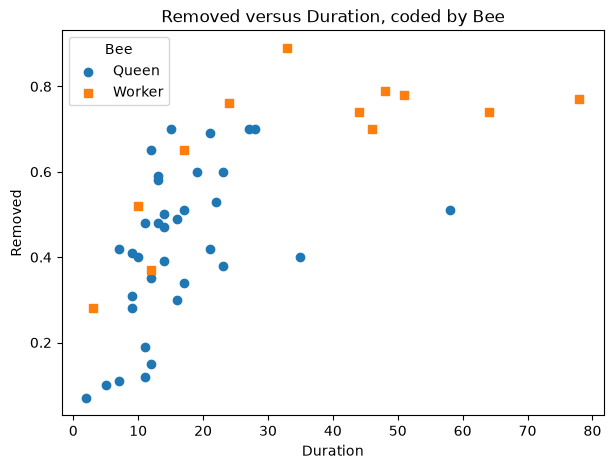

In [5]:
markers = ['o', 's']

fig, ax = plt.subplots(figsize=(7, 5))
for marker, (bee, group) in zip(markers, df.groupby('Bee')):
    ax.scatter(group['Duration'], group['Removed'], marker=marker, label=bee)

ax.set_xlabel('Duration')
ax.set_ylabel('Removed')
ax.set_title('Removed versus Duration, coded by Bee')
ax.legend(title='Bee')
plt.show()

Relationship between proportion removed and duration does not appear to be a straight line, especially for workers.

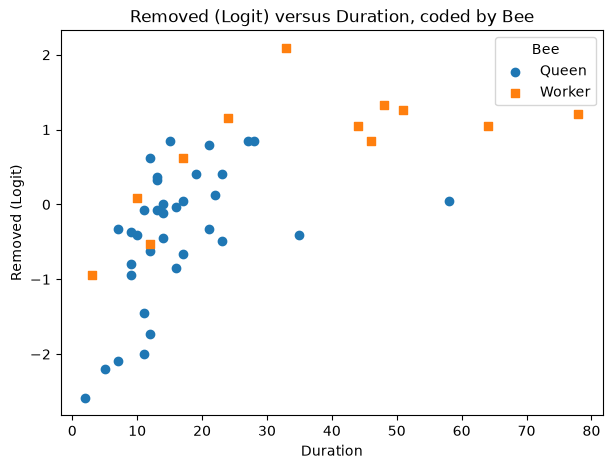

In [6]:
df['Removed_logit'] = np.log(df['Removed'] / (1 - df['Removed']))

fig, ax = plt.subplots(figsize=(7, 5))
for marker, (bee, group) in zip(markers, df.groupby('Bee')):
    ax.scatter(group['Duration'], group['Removed_logit'], marker=marker, label=bee)

ax.set_xlabel('Duration')
ax.set_ylabel('Removed (Logit)')
ax.set_title('Removed (Logit) versus Duration, coded by Bee')
ax.legend(title='Bee')
plt.show()

Relationship between the logit of proportion removed and duration also does not appear to be a straight line.

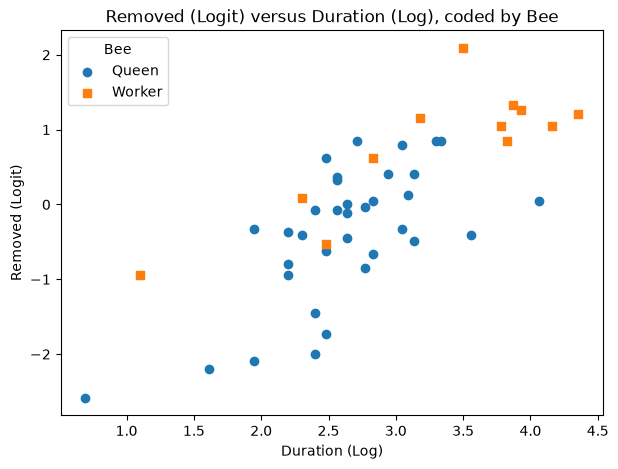

In [7]:
df['Duration_log'] = np.log(df['Duration'])

fig, ax = plt.subplots(figsize=(7, 5))
for marker, (bee, group) in zip(markers, df.groupby('Bee')):
    ax.scatter(group['Duration_log'], group['Removed_logit'], marker=marker, label=bee)

ax.set_xlabel('Duration (Log)')
ax.set_ylabel('Removed (Logit)')
ax.set_title('Removed (Logit) versus Duration (Log), coded by Bee')
ax.legend(title='Bee')
plt.show()

Points in the scatterplot of logit of proportion removed vs log duration appear to lie in a straight line. Thus we can attempt to fit a linear regression model to this case.

In [9]:
fm = ols(formula='Removed_logit ~ Duration_log * Bee', data=df).fit()
print(fm.summary2(),'\n')

                     Results: Ordinary least squares
Model:                 OLS                 Adj. R-squared:        0.588   
Dependent Variable:    Removed_logit       AIC:                   97.0709 
Date:                  2026-09-04 16:59    BIC:                   104.4715
No. Observations:      47                  Log-Likelihood:        -44.535 
Df Model:              3                   F-statistic:           22.90   
Df Residuals:          43                  Prob (F-statistic):    5.15e-09
R-squared:             0.615               Scale:                 0.42579 
--------------------------------------------------------------------------
                            Coef.  Std.Err.    t    P>|t|   [0.025  0.975]
--------------------------------------------------------------------------
Intercept                  -3.0390   0.5115 -5.9413 0.0000 -4.0705 -2.0074
Bee[T.Worker]               1.3770   0.8722  1.5788 0.1217 -0.3819  3.1359
Duration_log                1.0121   0.1902  5.

The p-value for the interaction term is 0.3416>0.05. Thus this is insufficient evidence that the proportion of pollen removed depends on the duration of visit differently for queens than for workers.

In [10]:
fm1 = ols(formula='Removed_logit ~ Duration_log + Bee', data=df).fit()
print(fm1.summary2(),'\n')

                 Results: Ordinary least squares
Model:              OLS              Adj. R-squared:     0.589   
Dependent Variable: Removed_logit    AIC:                96.0711 
Date:               2026-09-04 17:01 BIC:                101.6216
No. Observations:   47               Log-Likelihood:     -45.036 
Df Model:           2                F-statistic:        33.95   
Df Residuals:       44               Prob (F-statistic): 1.21e-09
R-squared:          0.607            Scale:              0.42507 
-----------------------------------------------------------------
                   Coef.  Std.Err.    t    P>|t|   [0.025  0.975]
-----------------------------------------------------------------
Intercept         -2.7146   0.3842 -7.0650 0.0000 -3.4890 -1.9402
Bee[T.Worker]      0.5697   0.2364  2.4095 0.0202  0.0932  1.0462
Duration_log       0.8886   0.1402  6.3391 0.0000  0.6061  1.1711
-----------------------------------------------------------------
Omnibus:               1.29

The p-value for BeeWorker is 0.0202<0.05. Hence, there is evidence that queens tend to remove a smaller proportion of pollens that workers. The p-value for BeeWorker is different because we are considering a different model with different predictors.

In [2]:
df = pd.read_csv('dataset/michiganacc.txt', sep='\t')
df['Season'] = pd.Categorical(df['Season'], categories=['Spring', 'Summer', 'Autumn', 'Winter'], ordered=True)
df['Month'] = pd.Categorical(df['Month'], categories=['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December'], ordered=True)
print(df.head(),'\n')

   Time  Season     Month  Unemployment_rate  Accidents
0     1  Winter   January               8.00         40
1     2  Winter  February               8.20         39
2     3  Spring     March               8.00         32
3     4  Spring     April               8.75         27
4     5  Spring       May               7.25         31 



In [12]:
df.isnull().sum()

Time                 0
Season               0
Month                0
Unemployment_rate    0
Accidents            0
dtype: int64

In [13]:
print(df.info(),'\n')

<class 'pandas.DataFrame'>
RangeIndex: 108 entries, 0 to 107
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   Time               108 non-null    int64   
 1   Season             108 non-null    category
 2   Month              108 non-null    category
 3   Unemployment_rate  108 non-null    float64 
 4   Accidents          108 non-null    int64   
dtypes: category(2), float64(1), int64(2)
memory usage: 3.5 KB
None 



In [26]:
fm1 = glm('Accidents ~ Season + Month + Unemployment_rate', df).fit()
print(fm1.summary2(),'\n')

                Results: Generalized linear model
Model:                 GLM               Method:          IRLS    
Model Family:          Gaussian          AIC:             641.2989
Link Function:         Identity          BIC:             676.1666
Dependent Variable:    Accidents         Log-Likelihood:  -307.65 
Date:                  2026-09-04 16:33  LL-Null:         -374.47 
No. Observations:      108               Deviance:        1884.6  
Df Model:              12                Pearson chi2:    1.88e+03
Df Residuals:          95                Scale:           19.838  
------------------------------------------------------------------
                    Coef.  Std.Err.    z    P>|z|   [0.025  0.975]
------------------------------------------------------------------
Intercept          36.2245   1.6261 22.2774 0.0000 33.0375 39.4116
Season[T.Summer]    3.1729   0.6892  4.6040 0.0000  1.8222  4.5236
Season[T.Autumn]    5.9861   0.6752  8.8655 0.0000  4.6627  7.3094
Season[T.Win

c:\Users\YuxinLi\anaconda3\envs\ST5213\Lib\site-packages\statsmodels\genmod\generalized_linear_model.py:1486: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  wls_results = wls_model.fit(method=wls_method2)


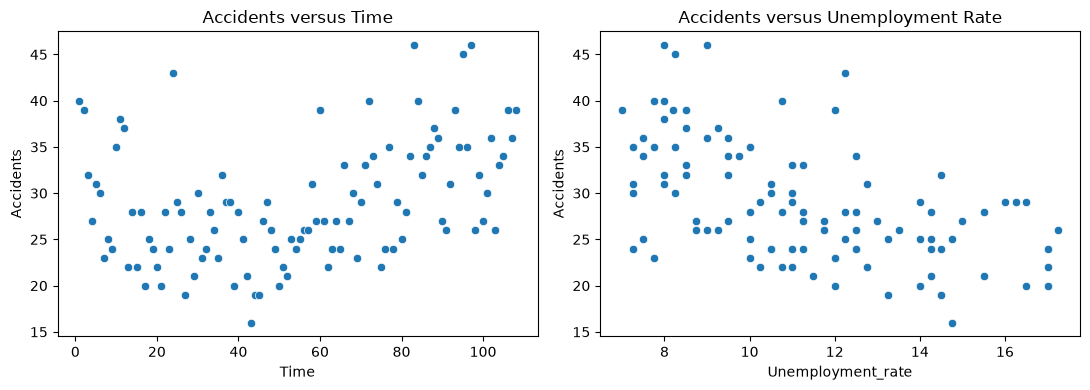

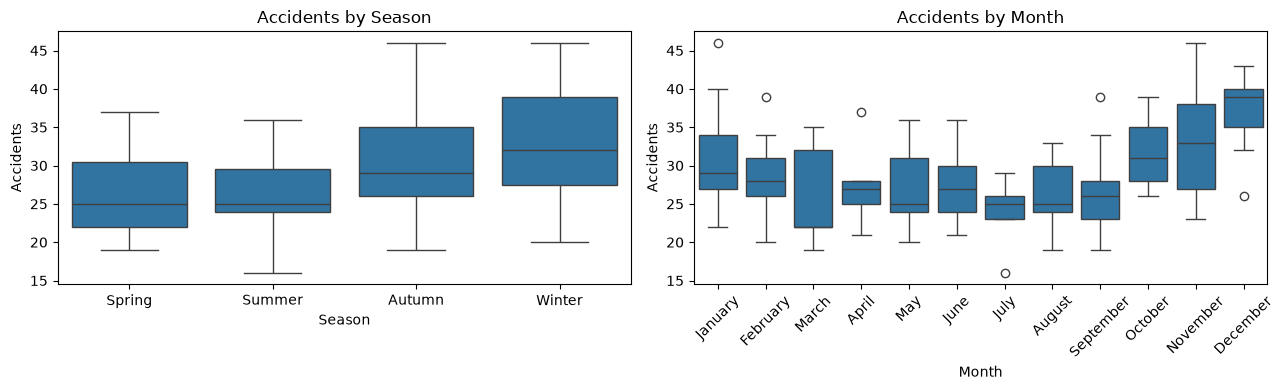

In [14]:
# Scatterplots of accidents against time and unemployment rate
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(11, 4))

sns.scatterplot(data=df, x='Time', y='Accidents', ax=axes[0])
axes[0].set_title('Accidents versus Time')

sns.scatterplot(data=df, x='Unemployment_rate', y='Accidents', ax=axes[1])
axes[1].set_title('Accidents versus Unemployment Rate')

plt.tight_layout()
plt.show()

# Boxplots of accidents by season and month
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(13, 4))

sns.boxplot(data=df, x='Season', y='Accidents', ax=axes[0])
axes[0].set_title('Accidents by Season')

sns.boxplot(data=df, x='Month', y='Accidents', ax=axes[1])
axes[1].set_title('Accidents by Month')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [15]:
fm_main = ols('Accidents ~ Time + Unemployment_rate + Season', df).fit()
fm_main.summary2()

<class 'statsmodels.iolib.summary2.Summary'>
"""
                 Results: Ordinary least squares
=================================================================
Model:              OLS              Adj. R-squared:     0.484   
Dependent Variable: Accidents        AIC:                645.1252
Date:               2026-09-04 17:06 BIC:                661.2180
No. Observations:   108              Log-Likelihood:     -316.56 
Df Model:           5                F-statistic:        21.07   
Df Residuals:       102              Prob (F-statistic): 2.05e-14
R-squared:          0.508            Scale:              21.792  
-----------------------------------------------------------------
                   Coef.  Std.Err.    t    P>|t|   [0.025  0.975]
-----------------------------------------------------------------
Intercept         38.0990   2.5213 15.1108 0.0000 33.0980 43.1000
Season[T.Summer]  -1.2676   1.2733 -0.9955 0.3219 -3.7932  1.2581
Season[T.Autumn]   2.4183   1.2839  1.8836 0.0625 -0.1283  4.9648
Season[T.Winter]   5.7046   1.2708  4.4890 0.0000  3.1839  8.2252
Time               0.0435   0.0150  2.8934 0.0047  0.0137  0.0734
Unemployment_rate -1.1847   0.1737 -6.8201 0.0000 -1.5292 -0.8401
-----------------------------------------------------------------
Omnibus:              0.708        Durbin-Watson:           1.997
Prob(Omnibus):        0.702        Jarque-Bera (JB):        0.377
Skew:                 0.124        Prob(JB):                0.828
Kurtosis:             3.149        Condition No.:           376  
=================================================================
Notes:
[1] Standard Errors assume that the covariance matrix of the
errors is correctly specified.
"""

In [17]:
fm1 = ols('Accidents ~ Time + Unemployment_rate', df).fit()
anova_lm(fm1, fm_main)

,df_resid,ssr,df_diff,ss_diff,F,Pr(>F)
0,105.0,2984.349062,0.0,NaN,NaN,NaN
1,102.0,2222.803936,3.0,761.545126,11.648591,0.000001


In [5]:
fm = ols('Accidents ~ (Time + Unemployment_rate + Season)**2', df).fit()
drop1_lm(fm)

,Df,RSS,AIC,F,Pr(>F)
<none>,,2102.268794,653.103972,,
Time:Season,3,2194.832248,651.757528,1.394292,0.249334
Unemployment_rate:Season,3,2123.900506,648.209581,0.32584,0.806667
Time:Unemployment_rate,1,2102.276572,651.104371,0.000351,0.985082


In [6]:
fm = ols('Accidents ~ Time*Season + Unemployment_rate*Season', df).fit()
drop1_lm(fm)

,Df,RSS,AIC,F,Pr(>F)
<none>,,2102.276572,651.104371,,
Time:Season,3,2196.938927,649.861140,1.440912,0.235695
Unemployment_rate:Season,3,2124.520819,646.241119,0.338593,0.797458


In [7]:
fm = ols('Accidents ~ Time*Season + Unemployment_rate', df).fit()
drop1_lm(fm)

,Df,RSS,AIC,F,Pr(>F)
<none>,,2124.520819,646.241119,,
Time:Season,3,2222.803936,645.125220,1.526623,0.212333
Unemployment_rate,1,3128.944798,686.053270,46.804895,0.0


In [14]:
fm = ols('Accidents ~ Time + Season + Unemployment_rate', df).fit()
drop1_lm(fm)

,Df,RSS,AIC,F,Pr(>F)
<none>,,2222.803936,645.125220,,
Season,3,2984.349062,670.943339,11.648591,0.000001
Time,1,2405.248914,651.644688,8.372033,0.004659
Unemployment_rate,1,3236.429285,683.700951,46.513228,0.0


All interaction terms were not statistically significant and were removed.

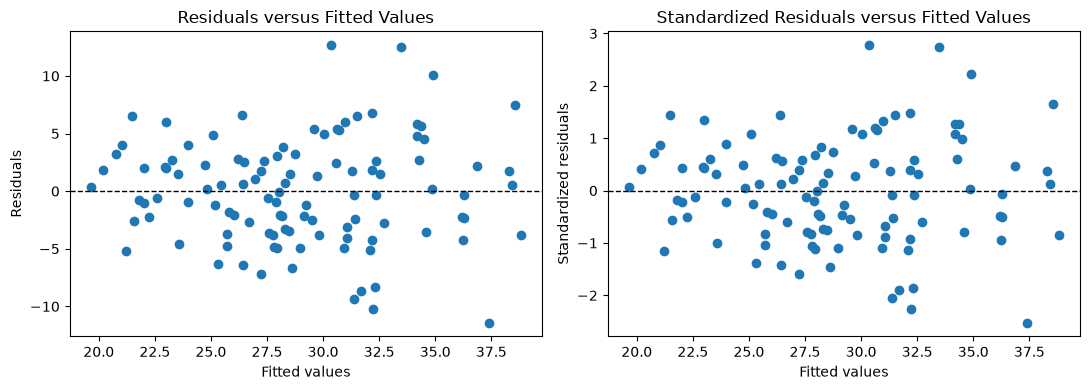

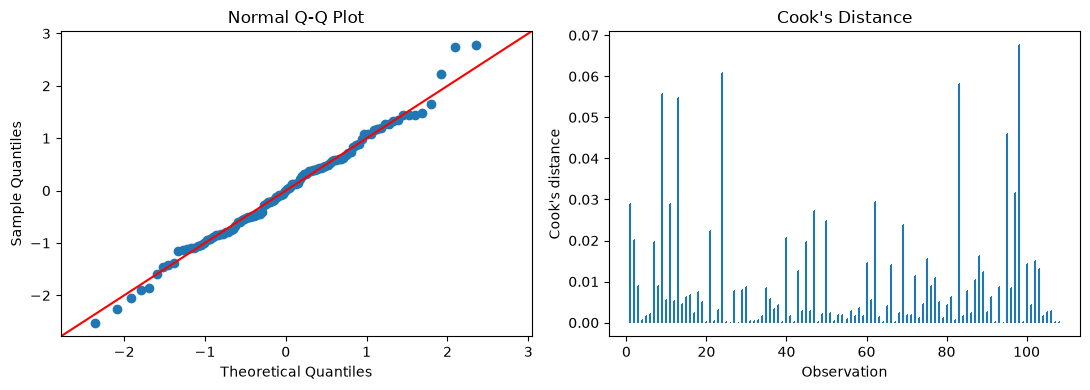

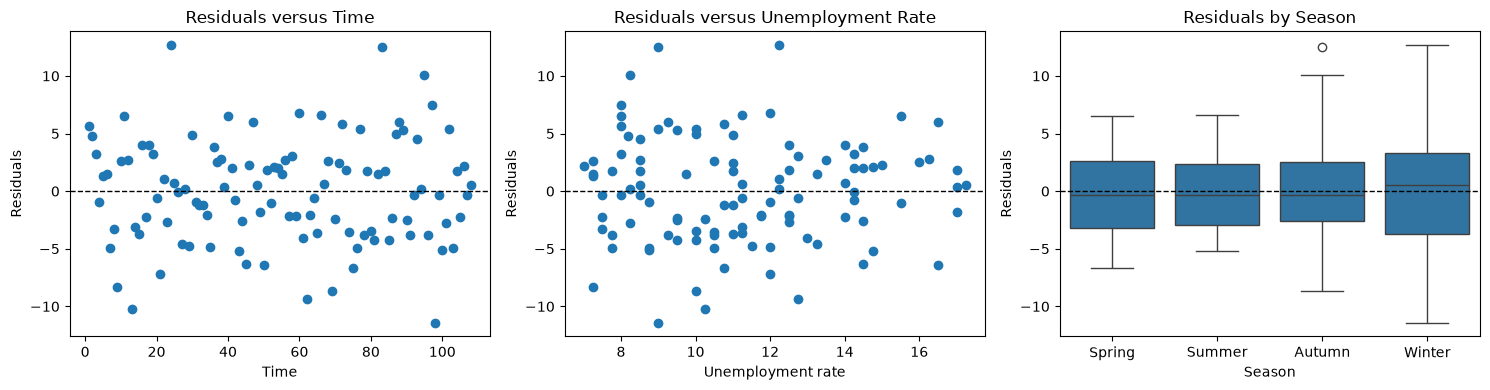

In [ ]:
from statsmodels.stats.outliers_influence import OLSInfluence
import statsmodels.api as sm

# Residual and influence quantities for the selected model fm
fitted_values = fm.fittedvalues
residuals = fm.resid
influence = OLSInfluence(fm)
standardized_residuals = influence.resid_studentized_internal
cooks_distance = influence.cooks_distance[0]

# Residuals and fitted values
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(11, 4))
axes[0].scatter(fitted_values, residuals)
axes[0].axhline(0, color='black', linestyle='--', linewidth=1)
axes[0].set_xlabel('Fitted values')
axes[0].set_ylabel('Residuals')
axes[0].set_title('Residuals versus Fitted Values')

axes[1].scatter(fitted_values, standardized_residuals)
axes[1].axhline(0, color='black', linestyle='--', linewidth=1)
axes[1].set_xlabel('Fitted values')
axes[1].set_ylabel('Standardized residuals')
axes[1].set_title('Standardized Residuals versus Fitted Values')
plt.tight_layout()
plt.show()

# Q-Q plot and Cook's distance
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(11, 4))
sm.qqplot(standardized_residuals, line='45', ax=axes[0])
axes[0].set_title('Normal Q-Q Plot')

observation_numbers = np.arange(1, len(cooks_distance) + 1)
axes[1].stem(observation_numbers, cooks_distance, markerfmt=',', basefmt=' ')
axes[1].set_xlabel('Observation')
axes[1].set_ylabel("Cook's distance")
axes[1].set_title("Cook's Distance")
plt.tight_layout()
plt.show()

# Residuals against the continuous and categorical predictors
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(15, 4))
axes[0].scatter(df['Time'], residuals)
axes[0].axhline(0, color='black', linestyle='--', linewidth=1)
axes[0].set_xlabel('Time')
axes[0].set_ylabel('Residuals')
axes[0].set_title('Residuals versus Time')

axes[1].scatter(df['Unemployment_rate'], residuals)
axes[1].axhline(0, color='black', linestyle='--', linewidth=1)
axes[1].set_xlabel('Unemployment rate')
axes[1].set_ylabel('Residuals')
axes[1].set_title('Residuals versus Unemployment Rate')

sns.boxplot(data=df.assign(Residuals=residuals), x='Season', y='Residuals', ax=axes[2])
axes[2].axhline(0, color='black', linestyle='--', linewidth=1)
axes[2].set_title('Residuals by Season')
plt.tight_layout()
plt.show()

There are a few months that are outlying and more influential.

The residuals vs fitted values plot indicates that the variance increases with the number of accidents.

The boxplots of residuals by season suggest higher variance in Autumn and Winter.

Weighted least squares can be used to address these problems.